# Task 1 [2 points]


1. Download and upload data from the category Sports and Outdoors:
https://cseweb.ucsd.edu/ jmcauley/datasets/amazon_v2/. Process the reviews into a pd.DataFrame
with columns [’user_id’, ’asin’, ’rating’, ’timestamp’]. Take care of the memory
usage of your implementation.


In [40]:
from pathlib import Path
import gc
import pandas as pd

REVIEWS_JSON = Path("data/Sports_and_Outdoors.json")

def load_reviews_naive(path):
    df = pd.read_json(
        path,
        lines=True,
        dtype={
            "reviewerID": "string",
            "asin": "string",
            "overall": "float32",
            "unixReviewTime": "int64",
        },
    )[["reviewerID", "asin", "overall", "unixReviewTime"]].rename(
        columns={
            "reviewerID": "user_id",
            "overall": "rating",
            "unixReviewTime": "timestamp",
        }
    )
    df["user_id"] = df["user_id"].astype("category")
    df["asin"] = df["asin"].astype("category")
    return df

def load_reviews_chunked(path, chunk_size=100000):
    required_cols = ["reviewerID", "asin", "overall", "unixReviewTime"]
    chunks = []

    # print("Processing chunks: ", end="")
    for i, chunk in enumerate(pd.read_json(path, lines=True, chunksize=chunk_size)):
        chunk = chunk[required_cols].rename(
            columns={
                "reviewerID": "user_id",
                "overall": "rating",
                "unixReviewTime": "timestamp",
            }
        )

        chunk["rating"] = chunk["rating"].astype("float32")
        chunk["timestamp"] = chunk["timestamp"].astype("int64")
        chunks.append(chunk)

        # if i % 10 == 0:
            # print(i, end=" ")
    # print()

    df = pd.concat(chunks, ignore_index=True)
    df["user_id"] = df["user_id"].astype("category")
    df["asin"] = df["asin"].astype("category")

    # release temporary chunk objects
    del chunks
    try:
        del chunk
    except NameError:
        pass
    gc.collect()

    return df


def test_loader(loader):
    print(f"Testing loader: {loader.__name__}")

    time_start = pd.Timestamp.now()
    df = loader(REVIEWS_JSON)
    time_end = pd.Timestamp.now()

    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")
    print(f"Time: {(time_end - time_start).total_seconds():.2f} seconds")
    print(f"Memory usage: {mem_mb:.2f} MB")
    print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")
    print (f"Unique users: {df['user_id'].nunique()}")
    print (f"Unique items: {df['asin'].nunique()}")
    print(df.dtypes)
    print(df.head())

    return df


In [41]:
reviews_df = test_loader(load_reviews_chunked)
print()
# reviews_df = test_loader(load_reviews_naive)

Testing loader: load_reviews_chunked
Loaded 12980837 rows with columns: ['user_id', 'asin', 'rating', 'timestamp']
Time: 142.79 seconds
Memory usage: 992.81 MB
Loaded 12980837 rows with columns: ['user_id', 'asin', 'rating', 'timestamp']
Unique users: 6703391
Unique items: 957764
user_id      category
asin         category
rating        float32
timestamp       int64
dtype: object
          user_id        asin  rating   timestamp
0  A23K73OVXJ04EG  0000031895     5.0  1391212800
1  A2681T699HV6H1  0000031895     4.0  1384905600
2  A374PA18DCGS5Y  0000031895     1.0  1477008000
3  A14PVW2N5YBWSA  0000031895     5.0  1476748800
4  A2KWBC44QI2567  0000031895     1.0  1476662400



2. What is the 5-core version?


5-core is version filtered version to include only users and items that have at least 5 interactions

3. Provide a basic data analysis for the full variant and the 5-core version:
- (a) number of interactions for each item (sort the counts for readability),
- (b) the distribution of users’ number of interactions,
- (c) calculate the sparsity (how many of the possible user-item pairs are present in the data),
- (d) check for duplicates of contradictory data,
- (e) other plots that you find interesting.



========== FULL ========== 

(b) User interactions distribution:
count    6.703391e+06
mean     1.936458e+00
std      2.683295e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      4.330000e+02
dtype: float64

(c) Sparsity:
users = 6703391, items = 957764
density = 12601954/6420266577724 = 0.00000196
sparsity = 0.99999804

(d) Duplicate/contradiction checks:
exact duplicates (same user,item,rating,timestamp): 369145
contradictory same-timestamp ratings: 1059
same user-item with different ratings over time: 3074

========== 5-CORE ========== 

(b) User interactions distribution:
count    332447.000000
mean          8.542535
std           6.518266
min           2.000000
25%           5.000000
50%           7.000000
75%           9.000000
max         371.000000
dtype: float64

(c) Sparsity:
users = 332447, items = 104687
density = 2679607/34802879089 = 0.00007699
sparsity = 0.99992301

(d) Duplicate/contradiction checks:
exact duplicates (sa

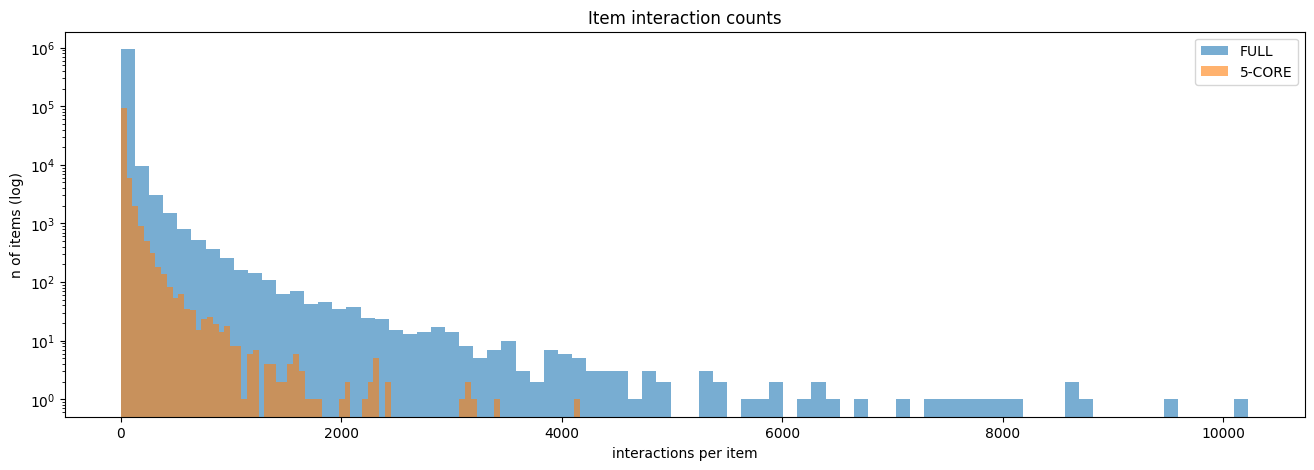

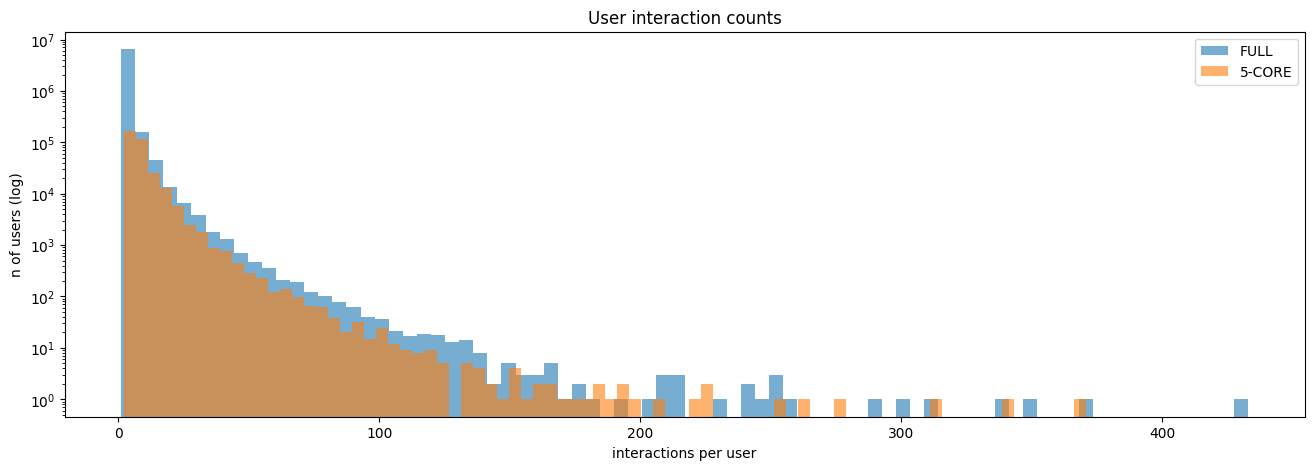

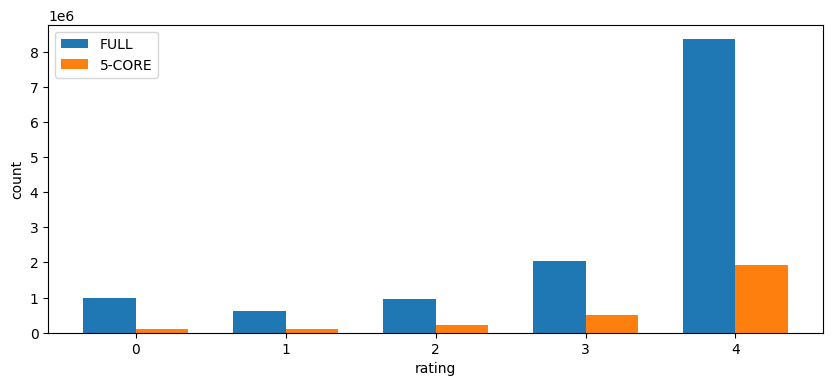

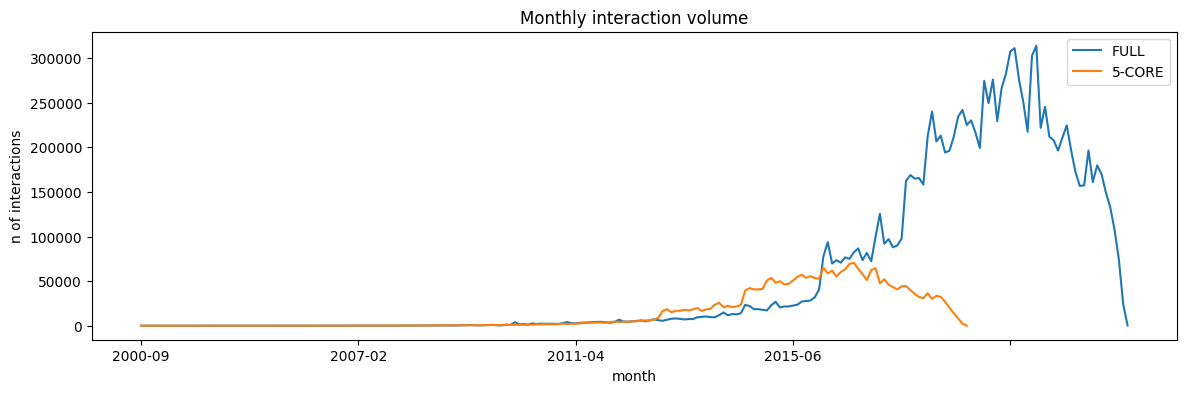

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_reviews(path):
    return load_reviews_chunked(path)

def plot_n_interactions_per_item(item_counts_list, names):
    plt.figure(figsize=(16, 5))
    for counts, name in zip(item_counts_list, names):
        plt.hist(counts, bins=80, alpha=0.6, label=name)
    plt.title("Item interaction counts")
    plt.xlabel("interactions per item")
    plt.ylabel("n of items (log)")
    plt.yscale("log")
    plt.legend()
    plt.show()

def plot_n_interactions_per_user(user_counts_list, names):
    plt.figure(figsize=(16, 5))
    for counts, name in zip(user_counts_list, names):
        plt.hist(counts, bins=80, alpha=0.6, label=name)
    plt.title("User interaction counts")
    plt.xlabel("interactions per user")
    plt.ylabel("n of users (log)")
    plt.yscale("log")
    plt.legend()
    plt.show()

def analyze(df, name, plot=True):
    print(f"\n========== {name} ========== ")

    # - (a) number of interactions for each item (sort the counts for readability),
    item_counts = df.groupby("asin", observed=True).size().sort_values(ascending=False)

    if plot:
        plot_n_interactions_per_item([item_counts], [name])

    # - (b) the distribution of users’ number of interactions,
    user_counts = df.groupby("user_id", observed=True).size()
    print("\n(b) User interactions distribution:")
    print(user_counts.describe())

    if plot:
        plot_n_interactions_per_user([user_counts], [name])

    # - (c) calculate the sparsity (how many of the possible user-item pairs are present in the data),
    n_users = df["user_id"].nunique()
    n_items = df["asin"].nunique()
    observed_pairs = df[["user_id", "asin"]].drop_duplicates().shape[0]
    possible_pairs = n_users * n_items
    density = observed_pairs / possible_pairs
    sparsity = 1.0 - density

    print("\n(c) Sparsity:")
    print(f"users = {n_users}, items = {n_items}")
    print(f"density = {observed_pairs}/{possible_pairs} = {density:.8f}")
    print(f"sparsity = {sparsity:.8f}")

    # - (d) check for duplicates of contradictory data,
    exact_dups = df.duplicated(subset=["user_id", "asin", "rating", "timestamp"]).sum()
    contradictory_same_time = (
        df.groupby(["user_id", "asin", "timestamp"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )
    changed_rating_over_time = (
        df.groupby(["user_id", "asin"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )

    print("\n(d) Duplicate/contradiction checks:")
    print(f"exact duplicates (same user,item,rating,timestamp): {exact_dups}")
    print(f"contradictory same-timestamp ratings: {contradictory_same_time}")
    print(f"same user-item with different ratings over time: {changed_rating_over_time}")

    # misc
    monthly_counts = (
        pd.to_datetime(df["timestamp"], unit="s")
        .dt.to_period("M")
        .astype(str)
        .value_counts()
        .sort_index()
    )

    return {
        "item_counts": item_counts,
        "user_counts": user_counts,
        "rating_counts": df["rating"].value_counts().sort_index(),
        "monthly_counts": monthly_counts,
    }


full_path = Path("data/Sports_and_Outdoors.json")
core_path = Path("data/Sports_and_Outdoors_5.json")

full_df = reviews_df if "reviews_df" in globals() else load_reviews(full_path)
core_df = load_reviews(core_path)

full_stats = analyze(full_df, "FULL", plot=False)
core_stats = analyze(core_df, "5-CORE", plot=False)

plot_n_interactions_per_item([full_stats["item_counts"], core_stats["item_counts"]], ["FULL", "5-CORE"])
plot_n_interactions_per_user([full_stats["user_counts"], core_stats["user_counts"]], ["FULL", "5-CORE"])

# rating ratio: 5-CORE / FULL
ratings = sorted(set(full_stats["rating_counts"].index).union(set(core_stats["rating_counts"].index)))
full_rc = np.array([full_stats["rating_counts"].get(r, 0) for r in ratings], dtype=float)
core_rc = np.array([core_stats["rating_counts"].get(r, 0) for r in ratings], dtype=float)
ratio = np.divide(core_rc, full_rc, out=np.full_like(core_rc, np.nan), where=full_rc != 0)

plt.figure(figsize=(10, 4))
plt.bar(ratings, ratio, width=0.6, label="5-CORE / FULL")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.xlabel("rating")
plt.ylabel("ratio")
plt.title("Rating count ratio between datasets")
plt.legend()
plt.show()

# monthly interaction
plt.figure(figsize=(14, 4))
full_stats["monthly_counts"].plot(label="FULL")
core_stats["monthly_counts"].plot(label="5-CORE")
plt.title("Monthly interaction volume")
plt.xlabel("month")
plt.ylabel("n of interactions")
plt.legend()
plt.show()

4. Consider the following train-test split procedures. What are their advantages and disadvan-
tages? Think of user and item representation, biases, leakage, and suitability for the ranking
task.
- Randomly select 20% of all interactions.
- Randomly select 20% of users and put all their interactions in the test set.
- Select 20% of interactions for each user at random.
- Select the most recent 20% of interactions for each user.
- Select a fixed number of the most recent interactions for each user to obtain around 20%
of the data.
- Select the most recent 20% of all interactions.


### Randomly select 20% of all interactions
**Advantages**
- simple
- popular (easier to compare)
- equal coverage of users and items in both train and test

**Disadvantages**
- temporal leakage - ttrain can contain future interactions, helping predict past ones
- shopaholic users can dominate metrics due to more test points

### Randomly select 20% of users and put all their interactions in test
**Advantages**
- user-level generalization - model must learn to represent unseen users (good for cold-start)
- no future-interaction leakage for predicted users

**Disadvantages**
- we still have future interaction leakage
- single-time users can dominate dataset


### Select 20% of interactions for each user at random
**Advantages**
- every user appears in both train and test (user representation is balanced)
- reduces dominance of very active users compared with global random split

**Disadvantages**
- temporal leakage
- can leak short-term preferences and make metrics look better than they really are
- rarely interacted items may still have weak train support


### Select the most recent 20% of interactions for each user
**Advantages**
- chronologically correct per user: train uses past, test uses future
- good for practical ranking/next-item recommendation
- every user is represented in train and test

**Disadvantages**
- bad for cold start - new users have no history
- users with very few interactions produce tiny/unstable/unconclusive data

### Select a fixed number of most recent interactions per user (to get ~20% total)
**Advantages**
- chronological
- each user contributes tests, consistent per-user test size

**Disadvantages**
- low-activity users may contribute very little train data, and lots of test data (unconclusive results)
- low-activity users may overweight metrics
- unbalanced user representattion

### Select the most recent 20% of all interactions (global time cutoff)
**Advantages**
- chronological, strongest anti-leakage in time
- may capture trends in time (seasonality)

**Disadvantages**
- some users may be underrepresented


5. Use the 5-core variant. Perform a train-test split by selecting the 2 most recent items for each
user for testing.


In [43]:
core_df_local = core_df.copy() if "core_df" in globals() else load_reviews(Path("data/Sports_and_Outdoors_5.json"))

# save index value as row_id
df = core_df_local.reset_index(drop=False).rename(columns={"index": "row_id"})

df = df.sort_values(["user_id", "timestamp", "row_id"], ascending=[True, False, False])

# rank user interactions
df["rank_recent"] = df.groupby("user_id", observed=True).cumcount()

test_mask = df["rank_recent"] < 2
test_df = df.loc[test_mask, ["user_id", "asin", "rating", "timestamp", "row_id"]].copy()
train_df = df.loc[~test_mask, ["user_id", "asin", "rating", "timestamp", "row_id"]].copy()

per_user_test_counts = test_df.groupby("user_id", observed=True).size()

n_users = df["user_id"].nunique()
n_interactions = len(df)
n_test = len(test_df)
n_train = len(train_df)

print(f"Users: {n_users}")
print(f"Interactions total: {n_interactions}")
print(f"Train interactions: {n_train}")
print(f"Test interactions: {n_test}")
print(f"Test ratio: {n_test / n_interactions:.4f}")
print("\nPer-user test interactions (describe):")
print(per_user_test_counts.describe())

# remove helper columns
train_split = train_df.drop(columns=["row_id"]).reset_index(drop=True)
test_split = test_df.drop(columns=["row_id"]).reset_index(drop=True)

print("\nTrain:")
display(train_split.head())
print("Test:")
display(test_split.head())

Users: 332447
Interactions total: 2839940
Train interactions: 2175046
Test interactions: 664894
Test ratio: 0.2341

Per-user test interactions (describe):
count    332447.0
mean          2.0
std           0.0
min           2.0
25%           2.0
50%           2.0
75%           2.0
max           2.0
dtype: float64

Train:


,user_id,asin,rating,timestamp
0,A0001528BGUBOEVR6T5U,B004E4AVY8,5.0,1439337600
1,A0001528BGUBOEVR6T5U,B0034XCI82,5.0,1439337600
2,A0001528BGUBOEVR6T5U,B0031YS5UY,5.0,1439337600
3,A0001528BGUBOEVR6T5U,B0009PUQ8M,5.0,1439337600
4,A0001528BGUBOEVR6T5U,B004I7D1WA,5.0,1410480000


Test:


,user_id,asin,rating,timestamp
0,A0001528BGUBOEVR6T5U,B012ZIGVXE,3.0,1478131200
1,A0001528BGUBOEVR6T5U,B007ZYH4BM,5.0,1439337600
2,A0024836TBQJ1WBE4VDY,B01AISP1KW,1.0,1530316800
3,A0024836TBQJ1WBE4VDY,B001GH4WD2,5.0,1527465600
4,A0029274J35Q1MYNKUWO,B0009349R8,5.0,1510790400


6. Think about how you can transform the data into boolean feedback.

- modelling only whether a user interacted positively with an item (`1`) or not observed (`0`, unknown)
- treating missing interactions as negative feedback
- treating repeated interactions as more positive feedback
- any interaction is positive

In [44]:
# first approach (monitor positive interactions)

df_core = core_df.copy() if "core_df" in globals() else load_reviews(Path("data/Sports_and_Outdoors_5.json"))

# based on plots, 4 is best
threshold = 4.0
df_pos = df_core.loc[df_core["rating"] >= threshold, ["user_id", "asin", "timestamp", "rating"]].copy()

# collapse repeated interactions to one event, keep last
df_pos = df_pos.sort_values(["user_id", "asin", "timestamp"]).drop_duplicates(["user_id", "asin"], keep="last")


implicit_df = df_pos[["user_id", "asin"]].copy()
implicit_df["feedback"] = 1
implicit_df["feedback"] = implicit_df["feedback"].astype("int8")

n_users = df_core["user_id"].nunique()
n_items = df_core["asin"].nunique()
n_total = len(df_core)
n_pos_raw = (df_core["rating"] >= threshold).sum()
n_pos_unique = len(implicit_df)
density = n_pos_unique / (n_users * n_items)

print(f"Total interactions: {n_total}")
print(f"Raw positive interactions: {n_pos_raw}")
print(f"Unique positive user-item pairs: {n_pos_unique}")
print(f"Users: {n_users}, items: {n_items}")
print(f"Matrix density: {density:.8f}")
print(f"Matrix sparsity: {1 - density:.8f}")

display(implicit_df.head())


Total interactions: 2839940
Raw positive interactions: 2416931
Unique positive user-item pairs: 2280461
Users: 332447, items: 104687
Matrix density: 0.00006553
Matrix sparsity: 0.99993447


,user_id,asin,feedback
32595,A0001528BGUBOEVR6T5U,B0002NY6SW,1
71996,A0001528BGUBOEVR6T5U,B0009PUQ8M,1
120740,A0001528BGUBOEVR6T5U,B000E7SY02,1
778828,A0001528BGUBOEVR6T5U,B001QBJT5Y,1
878743,A0001528BGUBOEVR6T5U,B002M4110K,1


# Task 2 [3 points]

1. Implement a baseline model that recommends the most popular items.
2. Provide an implementation of the Matrix Factorization model (suggested using PyTorch).
3. Enable the use of the following loss functions: MSE, BPR, Alignment+Uniformity.  
Are there any data transformations needed to apply those loss functions? Is sampling negative
examples necessary, and how can you perform it? Think of all possible options and implement
one of them.

4. Select appropriate hyper-parameters to avoid underfitting and overfitting during training. If
needed, use mini-batches for training. Monitor the training process (logs, wandb, ...).
5. For all loss functions, use the embedding dimensionality of 16, 32, 64, 128.
6. Compare the performance of the implemented models in terms of:
   - convergence speed,
   - recall@20,
   - hit-rate@20,
   - Normalized Discounted Cumulative Gain @20,
   - Mean Reciprocal Rank @20.

If you find the second task computationally too heavy, you can switch to Movielens-100k
https://grouplens.org/datasets/movielens/100k/.
You can obtain a point for implementing the popularity-based baseline with evaluation, a point for
complete experiments with one of the mentioned loss functions, and half a point for experiments
with each additional loss function.

In [45]:
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# threshold for classifying interactions as positive 
POS_THRESHOLD = 4.0

# split by most recent x interactions per user
def make_split(df, x_recent=2):
    tmp = df.reset_index(drop=False).rename(columns={"index": "row_id"})
    tmp = tmp.sort_values(["user_id", "timestamp", "row_id"], ascending=[True, False, False])
    tmp["rank_recent"] = tmp.groupby("user_id", observed=True).cumcount()

    test_mask = tmp["rank_recent"] < x_recent
    train_df = tmp.loc[~test_mask, ["user_id", "asin", "rating", "timestamp"]].reset_index(drop=True)
    test_df = tmp.loc[test_mask, ["user_id", "asin", "rating", "timestamp"]].reset_index(drop=True)
    return train_df, test_df


core_local = load_reviews("data/Sports_and_Outdoors_5.json")
train_split, test_split = make_split(core_local)

# convert to boolean positives
train_pos_df = train_split.loc[train_split["rating"] >= POS_THRESHOLD, ["user_id", "asin"]].drop_duplicates()
test_pos_df = test_split.loc[test_split["rating"] >= POS_THRESHOLD, ["user_id", "asin"]].drop_duplicates()

# keep only users with at least one positive in both train and test
trainable_users = set(train_pos_df["user_id"].unique())
eval_users_all = set(test_pos_df["user_id"].unique())
valid_users = trainable_users & eval_users_all
train_pos_df = train_pos_df[train_pos_df["user_id"].isin(valid_users)].copy()
test_pos_df = test_pos_df[test_pos_df["user_id"].isin(valid_users)].copy()

# create user and item indices
all_users = pd.Index(sorted(valid_users))
all_items = pd.Index(sorted(set(train_pos_df["asin"].unique()) | set(test_pos_df["asin"].unique())))

user2idx = {u: i for i, u in enumerate(all_users)}
item2idx = {it: j for j, it in enumerate(all_items)}
idx2item = {j: it for it, j in item2idx.items()}

# map to indices
train_pos_df["u"] = train_pos_df["user_id"].map(user2idx)
train_pos_df["i"] = train_pos_df["asin"].map(item2idx)
test_pos_df["u"] = test_pos_df["user_id"].map(user2idx)
test_pos_df["i"] = test_pos_df["asin"].map(item2idx)

# create user->set(items) for train and test
user_train_pos = defaultdict(set)
for row in train_pos_df[["u", "i"]].itertuples(index=False):
    user_train_pos[int(row.u)].add(int(row.i))

user_test_pos = defaultdict(set)
for row in test_pos_df[["u", "i"]].itertuples(index=False):
    user_test_pos[int(row.u)].add(int(row.i))

n_users = len(all_users)
n_items = len(all_items)

print(f"Users: {n_users}, Items: {n_items}")
print(f"Train positive pairs: {len(train_pos_df)}")
print(f"Test positive pairs: {len(test_pos_df)}")


Device: cuda
Users: 311501, Items: 104571
Train positive pairs: 1678517
Test positive pairs: 547331


In [46]:
def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)


def hit_rate_at_k(recommended, relevant, k):
    return 1.0 if len(set(recommended[:k]) & relevant) > 0 else 0.0


def ndcg_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    dcg = 0.0
    for rank, item in enumerate(rec_k, start=1):
        if item in relevant:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))

    return dcg / idcg


def mrr_at_k(recommended, relevant, k):
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            return 1.0 / rank
    return 0.0


def evaluate_ranker_for_users(score_fn, users, k=20):
    rows = []
    all_items_idx = np.arange(n_items)

    for u in users:
        # get relevant items for this user
        relevant = user_test_pos[u]
        if len(relevant) == 0:
            continue

        # get scores for all items
        scores = score_fn(u, all_items_idx)

        # exclude items seen in training
        train_seen = user_train_pos[u]
        if len(train_seen) > 0:
            scores[list(train_seen)] = -1e9

        # get top-k recommendations
        topk = np.argpartition(scores, -k)[-k:]
        topk = topk[np.argsort(scores[topk])[::-1]]
        rec = topk.tolist()

        # compute metrics
        rows.append(
            {
                f"recall@{k}": recall_at_k(rec, relevant, k),
                f"hit_rate@{k}": hit_rate_at_k(rec, relevant, k),
                f"ndcg@{k}": ndcg_at_k(rec, relevant, k),
                f"mrr@{k}": mrr_at_k(rec, relevant, k),
            }
        )

    # aggregate results
    dfm = pd.DataFrame(rows)
    return dfm.mean().to_dict() if len(dfm) else {
        f"recall@{k}": 0.0,
        f"hit_rate@{k}": 0.0,
        f"ndcg@{k}": 0.0,
        f"mrr@{k}": 0.0,
    }

In [47]:
# popularity baseline
item_pop = train_pos_df.groupby("i", observed=True).size().sort_values(ascending=False)

# precompute dense popularity scores for fast vectorized lookup.
pop_scores = np.zeros(n_items, dtype=np.float32)
pop_scores[item_pop.index.to_numpy(dtype=np.int64)] = item_pop.to_numpy(dtype=np.float32)


def popularity_score_fn(u, item_idx_array):
    return pop_scores[item_idx_array]


eval_users = sorted(user_test_pos.keys())
MAX_EVAL_USERS = min(500, len(eval_users))
eval_users = eval_users[:MAX_EVAL_USERS]

pop_metrics = evaluate_ranker_for_users(popularity_score_fn, eval_users, k=20)
print(f"Evaluated users: {len(eval_users)}")
print("Popularity baseline metrics:")
for k, v in pop_metrics.items():
    print(f"{k}: {v:.4f}")

Evaluated users: 500
Popularity baseline metrics:
recall@20: 0.0030
hit_rate@20: 0.0060
ndcg@20: 0.0010
mrr@20: 0.0005


In [48]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, emb_dim):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)

        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.item_emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def score(self, u, i):
        ue = self.user_emb(u)
        ie = self.item_emb(i)
        dot = (ue * ie).sum(dim=-1)
        return dot + self.user_bias(u).squeeze(-1) + self.item_bias(i).squeeze(-1)

    def embeddings(self, u, i):
        return self.user_emb(u), self.item_emb(i)


Data/loss notes:
- MSE: needs explicit targets for positive and negative pairs, so we sample negatives and use y in {0,1}.
- BPR: needs user-positive-negative triplets, so negative sampling is required.
- Alignment+Uniformity: works on positive pairs for alignment and all sampled embeddings for uniformity; negatives are not mandatory for the formula, but we still sample per batch to make item coverage wider.
- Implemented negative sampling option: uniform random item not in user history.
- Other valid options: popularity-weighted negatives, hard negatives from model top scores, in-batch negatives.

In [49]:
class PositivePairDataset(Dataset):
    def __init__(self, pairs_df):
        self.users = torch.tensor(pairs_df["u"].values, dtype=torch.long)
        self.items = torch.tensor(pairs_df["i"].values, dtype=torch.long)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx]


def sample_negative_items_for_users(users_np, user_pos_dict, n_items):
    neg = np.empty(len(users_np), dtype=np.int64)
    for t, u in enumerate(users_np):
        u = int(u)
        while True:
            j = np.random.randint(0, n_items)
            if j not in user_pos_dict[u]:
                neg[t] = j
                break
    return neg



In [50]:
def bpr_pairwise_loss(pos_score, neg_score):
    return -F.logsigmoid(pos_score - neg_score).mean()


def _sampled_uniformity_term(x, max_points=2048, pair_samples=32768):
    if x.size(0) > max_points:
        idx = torch.randperm(x.size(0), device=x.device)[:max_points]
        x = x[idx]

    n = x.size(0)
    if n < 2:
        return torch.tensor(0.0, device=x.device, dtype=x.dtype)

    m = min(pair_samples, n * (n - 1) // 2)
    idx1 = torch.randint(0, n, (m,), device=x.device)
    idx2 = torch.randint(0, n, (m,), device=x.device)
    same = idx1 == idx2
    if same.any():
        idx2[same] = (idx2[same] + 1) % n

    dist2 = (x[idx1] - x[idx2]).pow(2).sum(dim=1)
    return torch.log(torch.exp(-2.0 * dist2).mean() + 1e-12)

def alignment_uniformity_loss(u_emb, i_emb, max_points=2048, pair_samples=32768):
    u = F.normalize(u_emb, dim=1)
    i = F.normalize(i_emb, dim=1)

    align = (u - i).norm(dim=1).pow(2).mean()
    unif_users = _sampled_uniformity_term(u, max_points=max_points, pair_samples=pair_samples)
    unif_items = _sampled_uniformity_term(i, max_points=max_points, pair_samples=pair_samples)

    return align + unif_users + unif_items


In [51]:
from tqdm.auto import tqdm

def train_one_model(loss_name, emb_dim, train_pairs_df, n_epochs=8, batch_size=4096, lr=1e-3, wd=1e-5):
    model = MatrixFactorization(n_users, n_items, emb_dim).to(device)
    ds = PositivePairDataset(train_pairs_df)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    history = []
    t0 = time.perf_counter()

    for epoch in tqdm(range(1, n_epochs + 1), desc="Epochs", leave=False):
        model.train()
        running = 0.0
        seen = 0

        for u, i_pos in dl:
            u = u.to(device)
            i_pos = i_pos.to(device)
            bsz = u.size(0)

            opt.zero_grad()

            if loss_name == "MSE":
                users_np = u.detach().cpu().numpy()
                i_neg_np = sample_negative_items_for_users(users_np, user_train_pos, n_items)
                i_neg = torch.tensor(i_neg_np, dtype=torch.long, device=device)

                pos_score = model.score(u, i_pos)
                neg_score = model.score(u, i_neg)
                y_pos = torch.ones_like(pos_score)
                y_neg = torch.zeros_like(neg_score)
                loss = F.mse_loss(torch.sigmoid(pos_score), y_pos) + F.mse_loss(torch.sigmoid(neg_score), y_neg)

            elif loss_name == "BPR":
                users_np = u.detach().cpu().numpy()
                i_neg_np = sample_negative_items_for_users(users_np, user_train_pos, n_items)
                i_neg = torch.tensor(i_neg_np, dtype=torch.long, device=device)

                pos_score = model.score(u, i_pos)
                neg_score = model.score(u, i_neg)
                loss = bpr_pairwise_loss(pos_score, neg_score)

            elif loss_name == "A+U":
                u_emb, i_emb = model.embeddings(u, i_pos)
                loss = alignment_uniformity_loss(u_emb, i_emb)

            else:
                raise ValueError(f"Unsupported loss: {loss_name}")

            loss.backward()
            opt.step()

            running += float(loss.item()) * bsz
            seen += bsz

        epoch_loss = running / max(seen, 1)
        history.append(epoch_loss)
        # print(f"[{loss_name}][d={emb_dim}] epoch {epoch}/{n_epochs} loss={epoch_loss:.5f}")

    train_time = time.perf_counter() - t0
    return model, history, train_time


@torch.no_grad()
def mf_score_fn_factory(model):
    model.eval()
    item_tensor = torch.arange(n_items, device=device, dtype=torch.long)

    def score_fn(u_idx, item_idx_array):
        u = torch.full((len(item_idx_array),), int(u_idx), device=device, dtype=torch.long)
        i = torch.tensor(item_idx_array, device=device, dtype=torch.long)
        s = model.score(u, i)
        return s.detach().cpu().numpy()

    return score_fn

4. Select appropriate hyper-parameters to avoid underfitting and overfitting during training. If
needed, use mini-batches for training. Monitor the training process (logs, wandb, ...).



5. For all loss functions, use the embedding dimensionality of 16, 32, 64, 128.

In [52]:
from tqdm.auto import tqdm

EMBED_DIMS = [16, 32, 64, 128]
LOSSES = ["MSE", "BPR", "A+U"]
EPOCHS = 8
BATCH_SIZE = 4096

results = []
histories = {}

for loss_name in tqdm(LOSSES, desc="Losses"):
    for dim in tqdm(EMBED_DIMS, desc="Embedding dims", leave=False):
        model, history, train_time = train_one_model(
            loss_name=loss_name,
            emb_dim=dim,
            train_pairs_df=train_pos_df,
            n_epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            lr=1e-3,
            wd=1e-5,
        )

        metrics = evaluate_ranker_for_users(mf_score_fn_factory(model), eval_users, k=20)
        row = {
            "model": "MF",
            "loss": loss_name,
            "dim": dim,
            "train_time_sec": train_time,
            **metrics,
        }
        results.append(row)
        histories[(loss_name, dim)] = history

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["loss", "dim"]).reset_index(drop=True)
results_df

Losses:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding dims:   0%|          | 0/4 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

Epochs:   0%|          | 0/8 [00:00<?, ?it/s]

,model,loss,dim,train_time_sec,recall@20,hit_rate@20,ndcg@20,mrr@20
0,MF,A+U,16,203.784905,0.011,0.016,0.008260,0.008552
1,MF,A+U,32,166.303065,0.016,0.024,0.013248,0.015000
2,MF,A+U,64,181.427931,0.042,0.068,0.030495,0.035146
3,MF,A+U,128,190.886961,0.056,0.086,0.042613,0.051938
4,MF,BPR,16,327.366711,0.001,0.002,0.000409,0.000286
5,MF,BPR,32,200.373155,0.003,0.006,0.000986,0.000508
6,MF,BPR,64,221.373780,0.001,0.002,0.000437,0.000333
7,MF,BPR,128,245.808843,0.001,0.002,0.000409,0.000286
8,MF,MSE,16,293.067240,0.002,0.004,0.000697,0.000397
9,MF,MSE,32,199.888359,0.003,0.006,0.001010,0.000551


In [53]:
# include baseline row in the same comparison table
baseline_row = {
    "model": "Popularity",
    "loss": "-",
    "dim": 0,
    "train_time_sec": 0.0,
    **pop_metrics,
}

comparison_df = pd.concat([pd.DataFrame([baseline_row]), results_df], ignore_index=True)
comparison_df = comparison_df[[
    "model", "loss", "dim", "train_time_sec", "recall@20", "hit_rate@20", "ndcg@20", "mrr@20"
]]

print("Comparison table")
display(comparison_df.sort_values(["model", "loss", "dim"]))

# best config per loss by NDCG@20
best_per_loss = (
    results_df.sort_values(["loss", "ndcg@20"], ascending=[True, False])
    .groupby("loss", as_index=False)
    .first()
)

print("Best MF config per loss (by NDCG@20)")
display(best_per_loss[["loss", "dim", "train_time_sec", "recall@20", "hit_rate@20", "ndcg@20", "mrr@20"]])

# convergence speed proxy: final epoch loss and first-to-last drop ratio
conv_rows = []
for (loss_name, dim), hist in histories.items():
    if len(hist) > 1 and hist[0] != 0:
        drop_ratio = (hist[0] - hist[-1]) / abs(hist[0])
    else:
        drop_ratio = 0.0
    conv_rows.append({
        "loss": loss_name,
        "dim": dim,
        "loss_epoch1": hist[0],
        "loss_epoch_last": hist[-1],
        "relative_drop": drop_ratio,
    })

conv_df = pd.DataFrame(conv_rows).sort_values(["loss", "dim"])
print("Convergence summary")
display(conv_df)


Comparison table


,model,loss,dim,train_time_sec,recall@20,hit_rate@20,ndcg@20,mrr@20
1,MF,A+U,16,203.784905,0.011,0.016,0.008260,0.008552
2,MF,A+U,32,166.303065,0.016,0.024,0.013248,0.015000
3,MF,A+U,64,181.427931,0.042,0.068,0.030495,0.035146
4,MF,A+U,128,190.886961,0.056,0.086,0.042613,0.051938
5,MF,BPR,16,327.366711,0.001,0.002,0.000409,0.000286
6,MF,BPR,32,200.373155,0.003,0.006,0.000986,0.000508
7,MF,BPR,64,221.373780,0.001,0.002,0.000437,0.000333
8,MF,BPR,128,245.808843,0.001,0.002,0.000409,0.000286
9,MF,MSE,16,293.067240,0.002,0.004,0.000697,0.000397
10,MF,MSE,32,199.888359,0.003,0.006,0.001010,0.000551


Best MF config per loss (by NDCG@20)


,loss,dim,train_time_sec,recall@20,hit_rate@20,ndcg@20,mrr@20
0,A+U,128,190.886961,0.056,0.086,0.042613,0.051938
1,BPR,32,200.373155,0.003,0.006,0.000986,0.000508
2,MSE,32,199.888359,0.003,0.006,0.001010,0.000551


Convergence summary


,loss,dim,loss_epoch1,loss_epoch_last,relative_drop
8,A+U,16,-5.021710,-5.866452,0.168218
9,A+U,32,-5.503838,-6.369401,0.157265
10,A+U,64,-5.753015,-6.617463,0.150260
11,A+U,128,-5.877443,-6.713594,0.142264
4,BPR,16,0.668715,0.511344,0.235334
5,BPR,32,0.668691,0.511446,0.235153
6,BPR,64,0.668693,0.511444,0.235159
7,BPR,128,0.668679,0.511346,0.235289
0,MSE,16,0.487953,0.422832,0.133457
1,MSE,32,0.487948,0.422890,0.133331


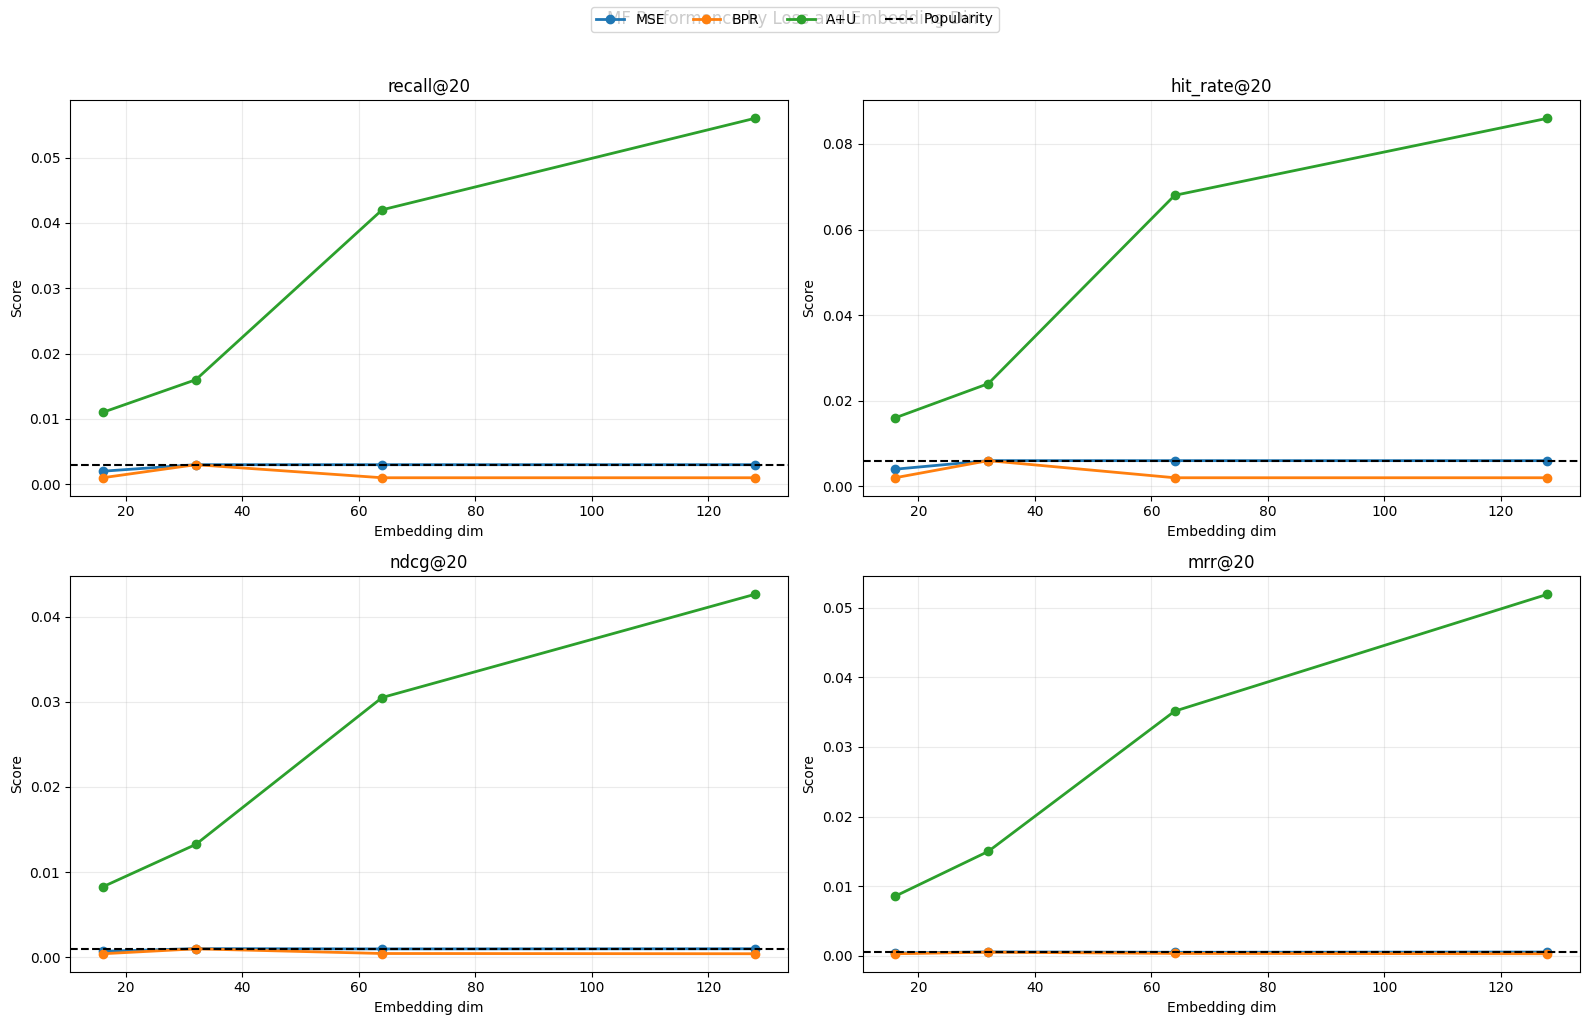

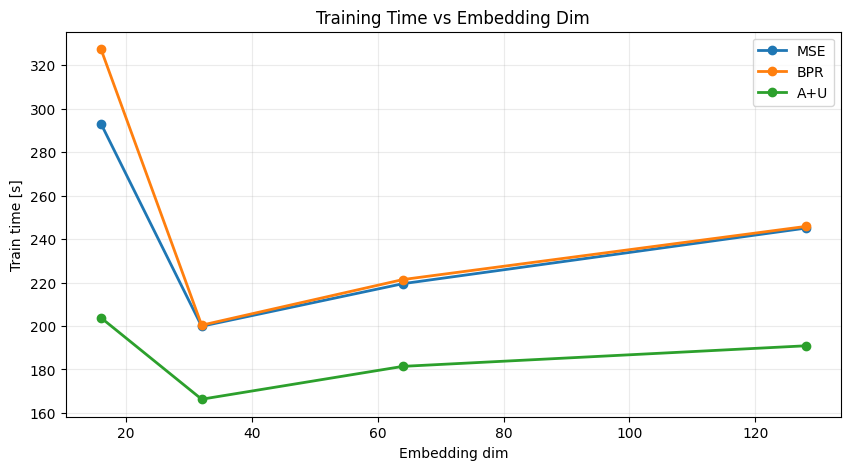

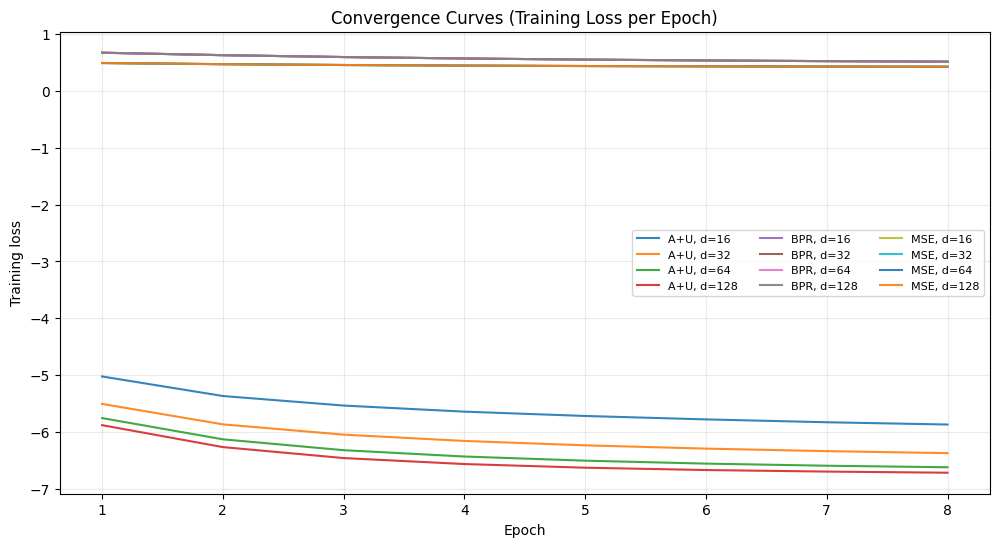

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metric_names = ["recall@20", "hit_rate@20", "ndcg@20", "mrr@20"]

for ax, metric in zip(axes.flat, metric_names):
    for loss_name in LOSSES:
        d = results_df[results_df["loss"] == loss_name].sort_values("dim")
        ax.plot(d["dim"], d[metric], marker="o", linewidth=2, label=loss_name)

    # baseline as a horizontal reference
    ax.axhline(pop_metrics[metric], linestyle="--", linewidth=1.5, color="black", label="Popularity" if metric == metric_names[0] else None)
    ax.set_title(metric)
    ax.set_xlabel("Embedding dim")
    ax.set_ylabel("Score")
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
fig.suptitle("MF Performance by Loss and Embedding Dim", y=1.02)
plt.tight_layout()
plt.show()

# Train time comparison
plt.figure(figsize=(10, 5))
for loss_name in LOSSES:
    d = results_df[results_df["loss"] == loss_name].sort_values("dim")
    plt.plot(d["dim"], d["train_time_sec"], marker="o", linewidth=2, label=loss_name)

plt.title("Training Time vs Embedding Dim")
plt.xlabel("Embedding dim")
plt.ylabel("Train time [s]")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Convergence curves across epochs
max_epochs_seen = max(len(h) for h in histories.values())
plt.figure(figsize=(12, 6))
for (loss_name, dim), hist in sorted(histories.items(), key=lambda x: (x[0][0], x[0][1])):
    epochs = np.arange(1, len(hist) + 1)
    plt.plot(epochs, hist, linewidth=1.5, alpha=0.9, label=f"{loss_name}, d={dim}")

plt.title("Convergence Curves (Training Loss per Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.xticks(np.arange(1, max_epochs_seen + 1))
plt.grid(alpha=0.25)
plt.legend(ncol=3, fontsize=8)
plt.show()